# Projet de Geostatistique 
                                                           réalisé par **Eunice Sitti-Mawubejro**

In [1]:
# imports #
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import isatis as isa

### 1. Importation et exploration des données

- Importons les données

In [2]:
point_data = pd.read_csv("./data.csv", sep=',') ## Importation
print (point_data) 

      Sample Number         X         Y       Z  Object ID  SN Key from lines  \
0                 1  32015.58  18844.02  268.26          1                  1   
1                 2  32018.57  18844.05  258.72          1                  2   
2                 3  32021.34  18844.05  249.11          1                  3   
3                 4  32023.74  18844.02  239.40          1                  4   
4                 5  32025.81  18843.99  229.62          1                  5   
...             ...       ...       ...     ...        ...                ...   
4389           4390  33926.33  20741.08  606.04        400               4390   
4390           4391  33927.36  20741.09  596.10        400               4391   
4391           4392  33928.23  20741.10  586.14        400               4392   
4392           4393  33928.49  20741.10  576.14        400               4393   
4393           4394  33928.53  20741.10  566.54        400               4394   

      Teneur  
0       0.24

Notre jeu de données est composé de 4394 ligne et 7 colonnes. Cela correspond à une table de 4394 observations et 7 variables. Il contient des données numériques. On pourrait penser que les colonnes X,Y,Z sont des coordonnées. Il ya également une colonne qui ne sert qu'à décompter le nombre de lignes (SN key from lines) et un colonne (Objet ID) pour les identifiants. Ces deux dernières ne sont pas pertinentes dans notre étude. Nous allons donc nous intéresser à X,Y,Z et Teneur avec un accent particulier sur ce dernier qui est notre variable d'intérêt. 

- Exploration des données 

In [3]:
point_data.tail(5) #voir les 5 derniers éléments

,Sample Number,X,Y,Z,Object ID,SN Key from lines,Teneur
4389,4390,33926.33,20741.08,606.04,400,4390,0.05
4390,4391,33927.36,20741.09,596.10,400,4391,0.10
4391,4392,33928.23,20741.10,586.14,400,4392,0.12
4392,4393,33928.49,20741.10,576.14,400,4393,0.16
4393,4394,33928.53,20741.10,566.54,400,4394,0.21


In [4]:
point_data.describe() ## retourne la table de statistique 

,Sample Number,X,Y,Z,Object ID,SN Key from lines,Teneur
count,4394.000000,4394.000000,4394.000000,4394.000000,4394.000000,4394.000000,4192.000000
mean,2197.500000,32975.182264,19794.340385,419.904178,200.138598,2197.500000,0.168242
std,1268.582871,576.280945,577.167526,119.776154,115.366065,1268.582871,0.059651
min,1.000000,32012.260000,18840.810000,171.040000,1.000000,1.000000,0.000000
25%,1099.250000,32455.372500,19249.792500,319.670000,100.250000,1099.250000,0.130000
50%,2197.500000,32936.880000,19749.945000,420.390000,200.000000,2197.500000,0.180000
75%,3295.750000,33435.595000,20248.757500,519.997500,300.000000,3295.750000,0.220000
max,4394.000000,33936.860000,20749.560000,671.880000,400.000000,4394.000000,0.260000


En regardant de près cette table statistique, on se rend compte que la variable Teneur contient des manquants. De plus, comme mentionné plus haut colonnes "SN Key from lines"	et "Object ID" ne semblent pas utile pour le moment. 
Fort de ces constats, nous allons "réduire" notre jeu de données pour une étude plus interessante. 
Pour ce faire, comme la proportion de manquant dans la colonne Teneur est assez petite (4,59%), nous allons exclure les lignes concernées et enlever les colonnes mentionnées plus haut.

- Préparation 

In [5]:
# dans un premier temps, je créé une copie du jeu de données avec les variables qui m'interessent
point_data_1 = point_data[['X','Y','Z','Object ID','Teneur']].copy()

# Ensuite, j'enlève les manquants de Teneur

point_data_1 = point_data_1.dropna(subset=['Teneur'])

# vérification : 

print(len( point_data) )# nombre de lignes initiale
print(len( point_data_1) )# nombre de lignes après nettoyage 





4394
4192


In [6]:
# les statistiques après nettoyage 
var_int = point_data_1['Teneur']
point_data_1.describe()

,X,Y,Z,Object ID,Teneur
count,4192.000000,4192.000000,4192.000000,4192.000000,4192.000000
mean,32976.174726,19795.880792,422.451307,200.404103,0.168242
std,575.562024,577.662172,119.247184,115.241764,0.059651
min,32012.260000,18840.810000,171.040000,1.000000,0.000000
25%,32514.822500,19317.512500,322.095000,101.000000,0.130000
50%,32937.020000,19840.015000,422.340000,200.000000,0.180000
75%,33434.965000,20339.977500,522.515000,300.000000,0.220000
max,33936.860000,20749.560000,671.880000,400.000000,0.260000


Après nettoyage, On a une table de 4192 observations. 
La variable Teneur est positive. Sa moyenne est de 0.168242 et  sa valeur maximale est 0.260000; ces deux valeurs sont assez proches. L'écart type de la variable est assez petit (0.059651); Cela pourrait suggérer que les différentes observations ne varie pas beaucoup autour de la moyenne avant d'atteindre la max.

- Analyse statistique 

In [7]:
var_int.describe()

count    4192.000000
mean        0.168242
std         0.059651
min         0.000000
25%         0.130000
50%         0.180000
75%         0.220000
max         0.260000
Name: Teneur, dtype: float64

Ce tableau confirme notre raisonnement. Cela pourrait traduire une homogénéité de la variable Teneur.

Text(0, 0.5, 'Fréquence')

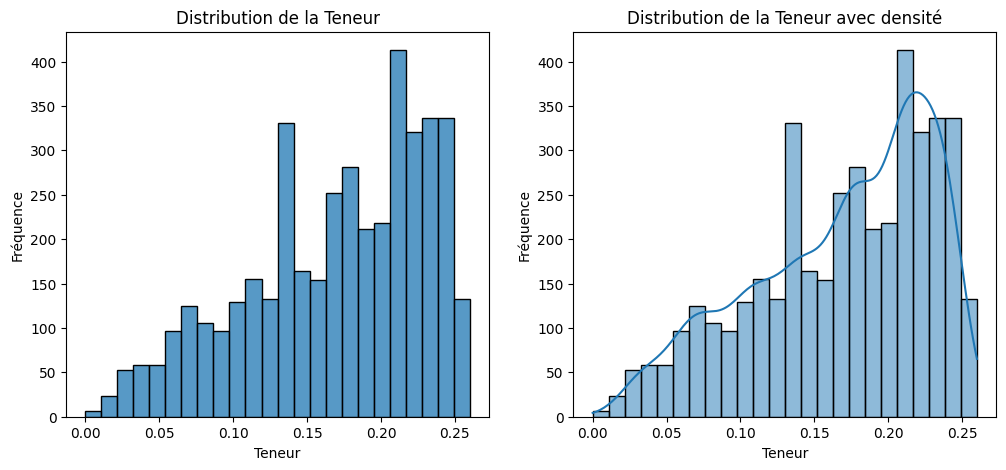

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(var_int)
plt.title('Distribution de la Teneur')
plt.xlabel('Teneur')
plt.ylabel('Fréquence')

plt.subplot(1, 2, 2)
sns.histplot(var_int,kde = True)
plt.title('Distribution de la Teneur avec densité')
plt.xlabel('Teneur')
plt.ylabel('Fréquence')

Cette distribution est assez asymétrique et ne ressemble en rien à une courbe en cloche. Elle s'étale plutot sur la gauche. On pourrait affimer que la distribution n'est donc pas Gaussienne. 

Text(0.5, 0, 'Teneur')

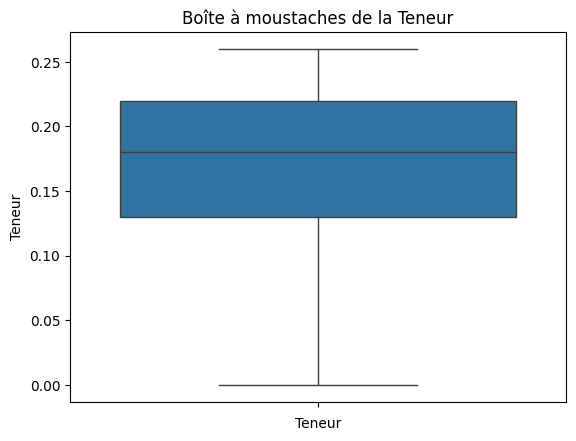

In [9]:
sns.boxplot(y = var_int)
plt.title('Boîte à moustaches de la Teneur')
plt.xlabel('Teneur')

En observant ce boxplot, on se rend compte qu'il y a pas de valeurs abérrantes; cela confirme une certaine homogénéité. De plus, le trait de la médiane semble légèrement plus haut que le milieu de la boite; cela traduit une asymétrie: on l'a remarqué sur l'histogramme. 

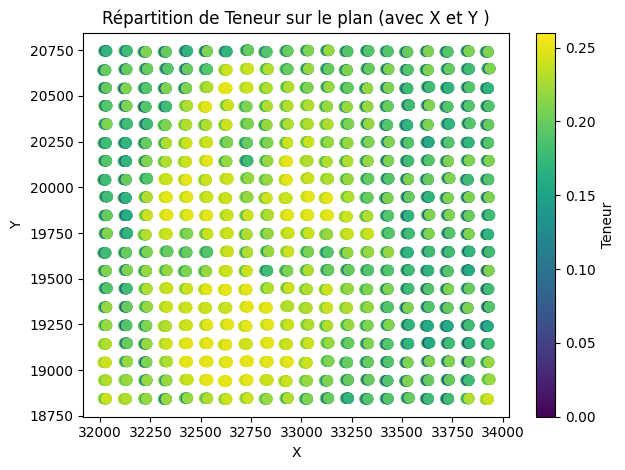

In [10]:
coords = point_data_1[['X','Y']].to_numpy()
var_int_1 = point_data_1[['Teneur']].to_numpy()
plt.scatter(coords[:,0],coords[:,1],c = var_int_1.flatten(),cmap='viridis',s=50)
plt.colorbar(label='Teneur')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Répartition de Teneur sur le plan (avec X et Y )')
plt.tight_layout()
plt.show()

Ici, on voit que dans le paln (X,Y) la variable Teneur est possitif, voire en majorité au delà de 0.10. Il y a une homogénéité qui est ici caractérisée par la présence dominante de beaucoup de vert. Mais, il y a quand même une petite zone (entre X=32250 et X=33000) où la teneur est assez élevée; caractérisée par la présence de jaune.

### 2. Variogramme 

- Variogramme expérimental

On réalise d'abord un variogramme expérimental pour voir comment se comporte les données.

In [11]:
# 1. Création de l'objet
input_db = isa.DbPandas(point_data_1)

# 3. Vérification
print(input_db)

print(input_db.df())

             X         Y       Z  Object ID  Teneur
0     32015.58  18844.02  268.26          1    0.24
1     32018.57  18844.05  258.72          1    0.22
2     32021.34  18844.05  249.11          1    0.21
3     32023.74  18844.02  239.40          1    0.20
4     32025.81  18843.99  229.62          1    0.18
...        ...       ...     ...        ...     ...
4389  33926.33  20741.08  606.04        400    0.05
4390  33927.36  20741.09  596.10        400    0.10
4391  33928.23  20741.10  586.14        400    0.12
4392  33928.49  20741.10  576.14        400    0.16
4393  33928.53  20741.10  566.54        400    0.21

[4192 rows x 5 columns]


In [12]:

bbox=input_db.bounding_box(sel=None, coords=['X', 'Y', 'Z'])
print(bbox)

# min et max des X
print(bbox[0][0])
print(bbox[0][1])

# min et max des Y
print(bbox[1][0])
print(bbox[1][1])

#min et max des Z
print(bbox[0][2])
print(bbox[1][2])

print(bbox)

[[np.float64(32012.26), np.float64(18840.81), np.float64(171.04)], [np.float64(33936.86), np.float64(20749.56), np.float64(671.88)]]
32012.26
18840.81
33936.86
20749.56
171.04
671.88
[[np.float64(32012.26), np.float64(18840.81), np.float64(171.04)], [np.float64(33936.86), np.float64(20749.56), np.float64(671.88)]]


In [13]:
x_min = bbox[0][0]
x_max = bbox[1][0]
y_min = bbox[0][1] 
y_max = bbox[1][1]
z_min = bbox[0][2]
z_max = bbox[1][2]

field_size_x = x_max - x_min
field_size_y = y_max - y_min
field_size_z = z_max - z_min

## calcul de la diag
#print(f"X range: {x_min} to {x_max} (size: {field_size_x})")
diagonal = np.sqrt(field_size_x**2 + field_size_y**2 +field_size_z**2)
print(diagonal)
lag = diagonal*(2/3)*(1/10)
print(lag)

2756.4927767182717
183.76618511455146


In [14]:
coords_name=['X', 'Y','Z']
vario = isa.Variogram()
vario.set_data(input_db, coords=coords_name, invars=['Teneur'])
vario_exp=vario.variogram(is_omnidirectional=True, lag_plane=lag, max_dist_plane=diagonal*(2/3))


(<Figure size 640x480 with 1 Axes>,
 array([[<Axes: xlabel='Distance', ylabel='Variogram(T)'>]], dtype=object))

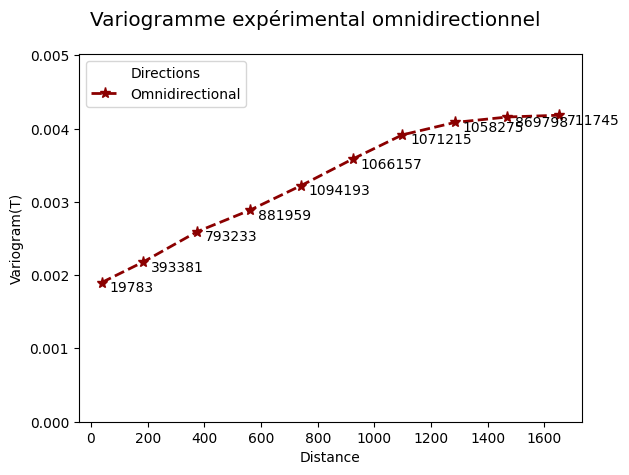

In [15]:

isa.display_fitting(vario_exp=vario_exp, title='Variogramme expérimental omnidirectionnel', names='Teneur',dist_max=diagonal, display_pair_numbers=True)

Notre variogramme expérimental est calculé avec un pas (lag) de 183.76618511455146. On observe une courbe qui croit lentement avant de "stagner" autour de 0.004 sur l'axe des Y. De plus, il y a un effet de pépite au début; un peu avant 0.002 sur l'axe des ordonnés.

In [16]:
vario_exp.to_curve()

,Distance,Number of pairs,Variogram
0,37.800167,19783.0,0.001901
1,183.334731,393381.0,0.002179
2,374.884234,793233.0,0.002595
3,561.272858,881959.0,0.002889
4,740.754675,1094193.0,0.003223
5,922.855744,1066157.0,0.003586
6,1098.439938,1071215.0,0.003916
7,1283.813198,1058275.0,0.004086
8,1469.437711,869798.0,0.004160
9,1651.969914,711745.0,0.004185


L'analyse des valeurs numérique du variogramme expérimental montre que la variance est assez faible (entre 0.0019 et 0.0041). 
Egalement, on peut dire que tout au long des distances, ces valeurs augmentent de manière assez régulière.
A partir de la ligne 7, il y a un ralentissement. 

- Variogramme associé

In [17]:
model = vario.fitting(vario_exp)

In [18]:
print(model.to_table())

                    Rx           Ry           Rz      Sill   A1   A2   A3
Nugget             NaN          NaN          NaN  0.001783  NaN  NaN  NaN
Spherical  1721.570456  1721.570456  1721.570456  0.002470  0.0  0.0  0.0


(<Figure size 640x480 with 1 Axes>,
 array([[<Axes: xlabel='Distance', ylabel='Variogram(T)'>]], dtype=object))

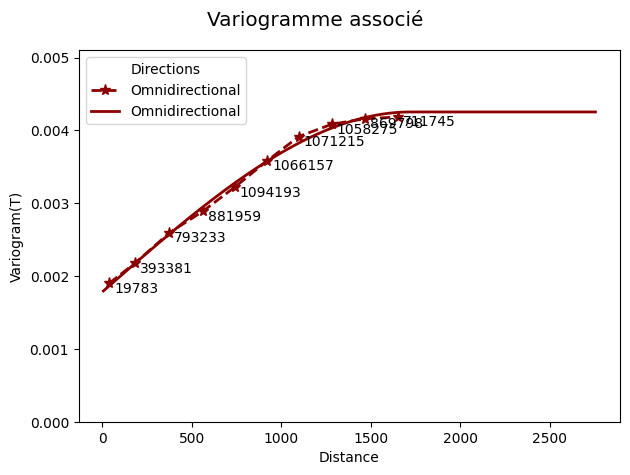

In [19]:

isa.display_fitting(vario_exp=vario_exp,vmodel=model, title='Variogramme associé', names='Teneur',dist_max=diagonal, display_pair_numbers=True)

Le variogramme associée s'ajuste parfaitement au variogramme expérimentale. Le choix du modèle sphérique avec un effet pepite à 0.001783 permet de capturer proprement les données. Ceci valide l'homogénéité observée dans la phase exploratoire. 

### 3. Création de la grille 

In [20]:
# Create the 3D grid support
orig = [32018, 18816,150]
n_cells = [60, 60,75]
cell_size = [33.33,33.33, 2.0]
grid = isa.GridGeom(
    ndim=3,
    origin=orig, 
    cell_size=cell_size, 
    nxyz=n_cells,
    rotation = isa.Rotation(0.0, -11.0,0.0),
    origin_cell_corner=False)
grid_db = isa.DbPandas(grid=grid)

##affichage
print(grid)

# examplaire = isa.DbPandas(point_data_1)


### 4.

- Interpolation plus proche voisins

In [21]:
grid_db = isa.DbPandas(grid=grid)
input_db = isa.DbPandas(point_data_1)

# QuickInterpolation calculator
runner = isa.QuickInterpol()
runner.set_input_data(input_db, coords=['X', 'Y','Z'], invars=['Teneur'])
runner.set_output_data(grid_db)





# Neighborhood


ellipsoid_size = [1000., 1000., 50.]
#rot = isa.Rotation(0.0, -11.0, 0.0)  
rot = isa.Rotation(a1=-11., convid=isa.CONV.GEOL_DIR)
#neigh = isa.Neigh(n_sectors=1, max_neigh_per_sector=4,ellipsoid_size=ellipsoid_size, rotation=rot)

# Nearest neighbors
outdb = runner.nearest_neighbor(ellipsoid_size, rotation=rot)

out_names = runner.out_names()
results = outdb.df()
results[out_names].describe()



,Teneur_nearest_neigh
count,270000.000000
mean,0.182607
std,0.055719
min,0.000000
25%,0.150000
50%,0.200000
75%,0.220000
max,0.260000


L'interpollation a produit 270 000 valeurs avec une moyenne de 0.182607  (légèrement plus élévé que celle des données initiales dont la moyenne était  0.168242 ) et un écart type plus ou moins pareil que celle des données initiales. Les valeurs min et max n'ont pas changées.

(<Figure size 640x480 with 2 Axes>,
 array([[<Axes: xlabel='Teneur_nearest_neigh'>]], dtype=object))

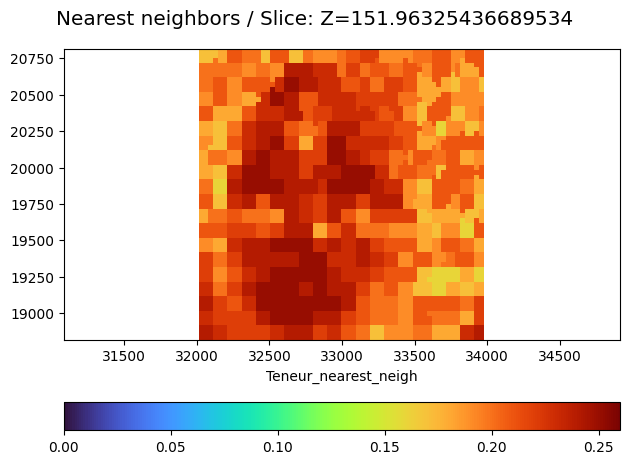

In [22]:
isa.display_grid(dbgrid=outdb, names=['Teneur_nearest_neigh'],
max_value=0.26, title="Nearest neighbors",equal_axis_aspect_ratio=True)

Ce résultat est assez fidèle à nos observations dans la partie 1. En effet, ici on observe une forte teneur entre 32000 et 34000 ce qui était aussi le cas des données initiales.

- Interpolation Moyenne Mobile 

In [23]:

# Neighborhood


ellipsoid_size = [1000., 1000., 50.]
#rot = isa.Rotation(0.0, -11.0, 0.0)  
rot = isa.Rotation(a1=-11., convid=isa.CONV.GEOL_DIR)
neigh = isa.Neigh(n_sectors=4, max_neigh_per_sector=4,ellipsoid_size=ellipsoid_size, rotation=rot)


# Moving average
outdbma = runner.moving_average(neigh=neigh)

out_names = runner.out_names()
results = outdbma.df()
results[out_names].describe()

,Teneur_moving_average
count,270000.000000
mean,0.179723
std,0.041629
min,0.048333
25%,0.154375
50%,0.186250
75%,0.213125
max,0.248750


Comme avant, on a 270 000 blocs. Cependant, la moyenne, l'écart type, le min et le max ont légèrement changé. 
En effet, le max ici est de 0.248750 (plus petit que initialement); le min a augmenté.

(<Figure size 640x480 with 2 Axes>,
 array([[<Axes: xlabel='Teneur_nearest_neigh'>]], dtype=object))

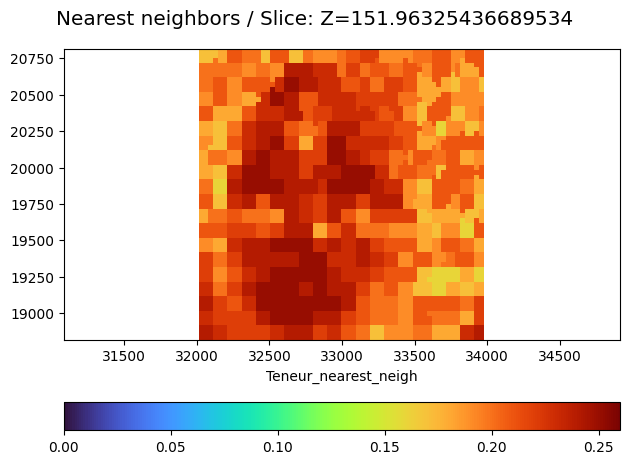

In [24]:
isa.display_grid(dbgrid=outdbma, names=['Teneur_nearest_neigh'],
max_value=0.26, title="Nearest neighbors",equal_axis_aspect_ratio=True)

Comme dans le cas des plus proche voisins, on observe  une forte teneur entre 32000 et 34000

- Krigeage 

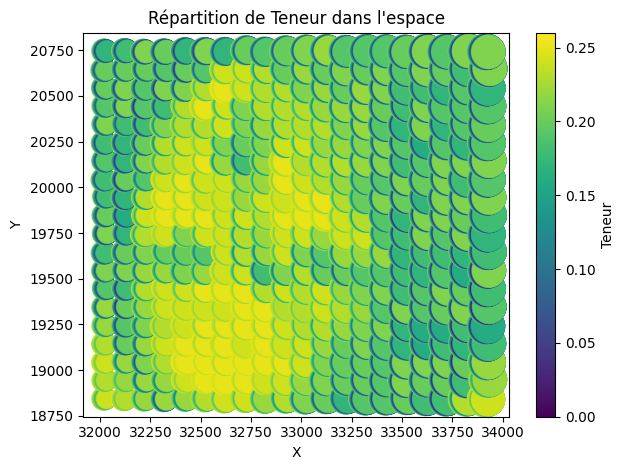

In [25]:
plt.scatter(point_data_1['X'], point_data_1['Y'],point_data_1['Z'], c=point_data_1['Teneur'], cmap='viridis')
plt.colorbar(label='Teneur')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Répartition de Teneur dans l\'espace')
plt.tight_layout()
plt.show()

- Krigeage Linéaire 

In [26]:

# QuickInterpolation calculator
runner = isa.QuickInterpol()
runner.set_input_data(input_db, coords=['X', 'Y','Z'], invars=['Teneur'])
#outdb = isa.DbPandas(grid=grid)
runner.set_output_data(grid_db)

# Linear kriging with unique neigh
outdb = runner.linear_kriging(neigh=neigh)

out_names = runner.out_names()
results = outdb.df()
results[out_names].describe()



,Teneur_linear_kriging
count,270000.000000
mean,0.183545
std,0.052571
min,0.000944
25%,0.154408
50%,0.198933
75%,0.223916
max,0.263155


Le krigeage linéaire offre une approximation à mis chemin entre le plus proche voisin et la moyenne mobile,  avec une moyenne de 0.183545 et un ecart type de 0.052571.

(<Figure size 640x480 with 2 Axes>,
 array([[<Axes: xlabel='Teneur_linear_kriging'>]], dtype=object))

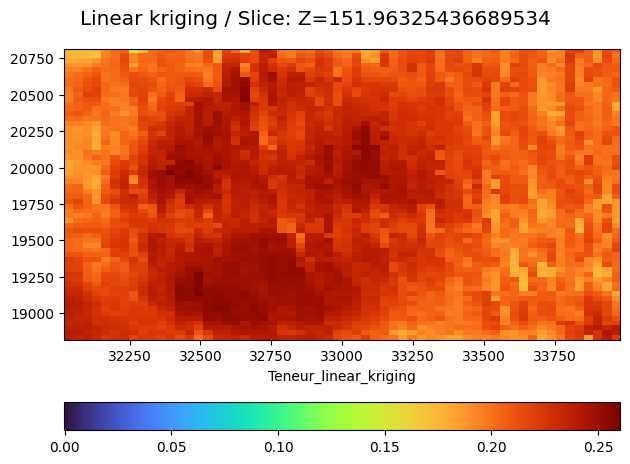

In [27]:
isa.display_grid(dbgrid=outdb, names=['Teneur_linear_kriging'], max_value=0.260269,min_value= -0.000454, title="Linear kriging")

- Un slice

(<Figure size 640x480 with 2 Axes>,
 array([[<Axes: xlabel='Teneur_linear_kriging'>]], dtype=object))

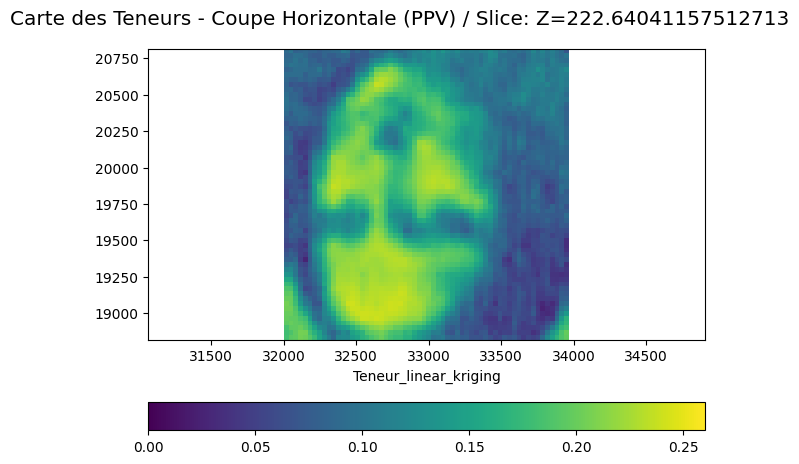

In [28]:
import isatis.constants as cst 

isa.display_grid(dbgrid=outdb, 
                 names=[out_names[0]], 
                 section_type=cst.SECTION.XOY, 
                 slice_index=37, 
                 max_value=0.26, 
                 title="Carte des Teneurs - Coupe Horizontale (PPV)",
                 cmap='viridis', 
                 equal_axis_aspect_ratio=True)

Au final, On peut reconnaitre Mona Lisa à  l'envers